In [30]:
import pandas as pd

In [31]:
#Nokia

In [32]:
df = pd.read_csv('nokia_predicted_output.csv')
df.columns

Index(['Unnamed: 0.13', 'Unnamed: 0.12', 'Unnamed: 0.11', 'Unnamed: 0.10',
       'Unnamed: 0.9', 'Unnamed: 0.8', 'Unnamed: 0.7', 'Unnamed: 0.6',
       'Unnamed: 0.5', 'Unnamed: 0.4', 'Unnamed: 0.3', 'Unnamed: 0.2',
       'Unnamed: 0', 'Unnamed: 0.1', 'msg_type', 'datetime', 'title',
       'thread_id', 'comment_id', 'topic_name_top', 'topic_name_leaf',
       'thread_text', 'date', 'thread_text_translated', 'emotion',
       'llm_emotion', 'normllm_emo', 'government_sentiment',
       'health_sentiment', 'community_sentiment', 'misinformation_sentiment',
       'overall_sentiment', 'title_translated', 'overall_sentiment_label',
       'government_sentiment_label', 'health_sentiment_label',
       'community_sentiment_label', 'misinformation_sentiment_label',
       'processed_thread_text', 'transprocessed_thread_text',
       'fin_sentiment_score', 'eng_sentiment_score', 'fin_sentiment_label',
       'eng_sentiment_label', 'topic_name', 'llmtopic_name', 'fisentiment',
       'ensent

In [33]:
df['predictedemotion'].value_counts()

predictedemotion
disgust     1421
neutral     1282
anger       1262
sadness      194
fear         140
surprise     116
joy            6
Name: count, dtype: int64

In [34]:
df['date'] = pd.to_datetime(df['date'])
# Get the minimum date
min_date = df['date'].min()

# Create custom week number starting from 1
df['week_number'] = ((df['date'] - min_date).dt.days // 7) + 1


df['week_number'].value_counts()

week_number
2     653
1     407
3     356
10    352
9     323
13    321
6     318
12    290
11    285
7     281
8     273
4     261
5     211
14     90
Name: count, dtype: int64

In [35]:
# Group by custom week_number and get min and max date per group
week_ranges = df.groupby('week_number')['date'].agg(['min', 'max']).reset_index()
week_ranges.columns = ['week_number', 'start_date', 'end_date']

print(week_ranges)

    week_number start_date   end_date
0             1 2007-11-27 2007-12-03
1             2 2007-12-04 2007-12-10
2             3 2007-12-11 2007-12-17
3             4 2007-12-18 2007-12-24
4             5 2007-12-25 2007-12-31
5             6 2008-01-01 2008-01-07
6             7 2008-01-08 2008-01-14
7             8 2008-01-15 2008-01-21
8             9 2008-01-22 2008-01-28
9            10 2008-01-29 2008-02-04
10           11 2008-02-05 2008-02-11
11           12 2008-02-12 2008-02-18
12           13 2008-02-19 2008-02-25
13           14 2008-02-26 2008-02-27


In [36]:
import pandas as pd

df['date'] = pd.to_datetime(df['date'])
min_date = df['date'].min()

# Create custom week number starting from 1
df['week_number'] = ((df['date'] - min_date).dt.days // 7) + 1

# Group by custom week_number and get min and max date per group
week_ranges = df.groupby('week_number')['date'].agg(['min', 'max']).reset_index()
week_ranges.columns = ['week_number', 'start_date', 'end_date']

# Create formatted week label like "27.11 - 03.12"
week_ranges['week'] = week_ranges.apply(
    lambda x: f"{x['start_date'].day:02d}.{x['start_date'].month:02d} - {x['end_date'].day:02d}.{x['end_date'].month:02d}",
    axis=1
)

# Merge back to df
df = df.merge(week_ranges[['week_number', 'week']], on='week_number', how='left')

print(df[['date', 'week_number', 'week']].head())


        date  week_number           week
0 2007-12-11            3  11.12 - 17.12
1 2007-12-13            3  11.12 - 17.12
2 2007-12-10            2  04.12 - 10.12
3 2007-12-10            2  04.12 - 10.12
4 2007-12-30            5  25.12 - 31.12


C:\Users\WGuser\AppData\Local\Temp\ipykernel_6824\3307306456.py:65: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')
C:\Users\WGuser\AppData\Local\Temp\ipykernel_6824\3307306456.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')


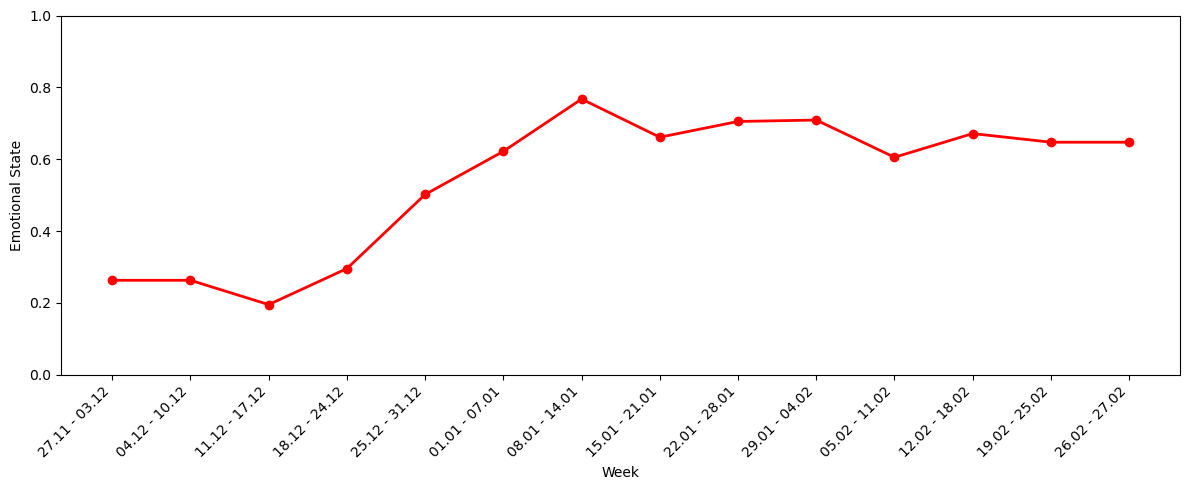

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Aggregate emotions per week
# -----------------------------

# Make sure weeks are in order
df = df.sort_values('week_number')

# Count how many times each emotion appears per week_number
emotion_counts = (
    df.groupby(['week_number', 'predictedemotion'])
      .size()
      .unstack(fill_value=0)
)

# Ensure all emotion columns exist (including surprise)
all_emotions = ['anger', 'fear', 'disgust', 'sadness', 'joy', 'neutral', 'surprise']
for e in all_emotions:
    if e not in emotion_counts.columns:
        emotion_counts[e] = 0

# Sort by week_number just to be safe
emotion_counts = emotion_counts.sort_index()

# -----------------------------------
# 2. Convert counts to proportions (%)
# -----------------------------------

emotion_props = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

# ---------------------------------------------------
# 3. FEMA-style emotional elevation index (HIGH = good)
# ---------------------------------------------------
# Positive / stabilising: joy + neutral
# Negative / distress: anger + fear + disgust + sadness + surprise

emotion_props['emotional_elevation'] = (
    emotion_props[['joy', 'neutral']].sum(axis=1)
    - emotion_props[['anger', 'fear', 'disgust', 'sadness', 'surprise']].sum(axis=1)
)

# -------------------------------
# 4. Normalise elevation to 0–1
# -------------------------------

x = emotion_props['emotional_elevation']
emin, emax = x.min(), x.max()

if emax > emin:
    emotion_props['elev_scaled'] = (x - emin) / (emax - emin)
else:
    # Edge case: if all weeks have same value
    emotion_props['elev_scaled'] = 0.5

# -------------------------------
# 5. Smooth the curve (rolling)
# -------------------------------

emotion_props['elev_smooth'] = (
    emotion_props['elev_scaled']
    .rolling(window=3, center=True)   # you can change window size (e.g., 2 or 4)
    .mean()
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ---------------------------------------
# 6. Attach human-readable week labels
# ---------------------------------------

week_labels = (
    df[['week_number', 'week']]
    .drop_duplicates()
    .sort_values('week_number')
)

plot_df = (
    emotion_props
    .reset_index()  # bring week_number out of the index
    .merge(week_labels, on='week_number', how='left')
)

# ----------------
# 7. Plot the line
# ----------------

plt.figure(figsize=(12, 5))

#Example: mark approximate phase transitions by week_number


plt.plot(plot_df['week'], plot_df['elev_smooth'],
         marker='o', linewidth=2, color='red')

plt.xlabel("Week")
plt.ylabel("Emotional State")
# plt.title("FEMA-style Emotional Trajectory – Nokia Water Crisis")
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])


plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('nokia_fema_emotional_elevation_curve.png', dpi=300)
plt.show()



In [7]:
import pandas as pd
import re

def dataset_statistics(df, date_col='date', text_col='thread_text_translated'):
    # Ensure date column is datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Tokenize by splitting on whitespace after removing punctuation
    df['tokens'] = df[text_col].apply(lambda x: re.findall(r'\w+', str(x).lower()))
    token_counts = df['tokens'].apply(len)

    # Average tokens per comment
    avg_tokens_per_comment = token_counts.mean()

    # Min & max tokens per comment
    min_tokens = token_counts.min()
    max_tokens = token_counts.max()

    # Average comments per day
    comments_per_day = df.groupby(df[date_col].dt.date).size()
    avg_comments_per_day = comments_per_day.mean()

    # Vocabulary size (unique words)
    vocab = set([token for tokens in df['tokens'] for token in tokens])
    vocab_size = len(vocab)

    return {
        'Average Tokens per Comment': round(avg_tokens_per_comment, 2),
        'Min Tokens per Comment': min_tokens,
        'Max Tokens per Comment': max_tokens,
        'Average Comments per Day': round(avg_comments_per_day, 2),
        'Vocabulary Size': vocab_size
    }

# Example usage:
stats = dataset_statistics(df)
print(stats)

{'Average Tokens per Comment': np.float64(100.61), 'Min Tokens per Comment': 1, 'Max Tokens per Comment': 1870, 'Average Comments per Day': np.float64(48.05), 'Vocabulary Size': 19951}


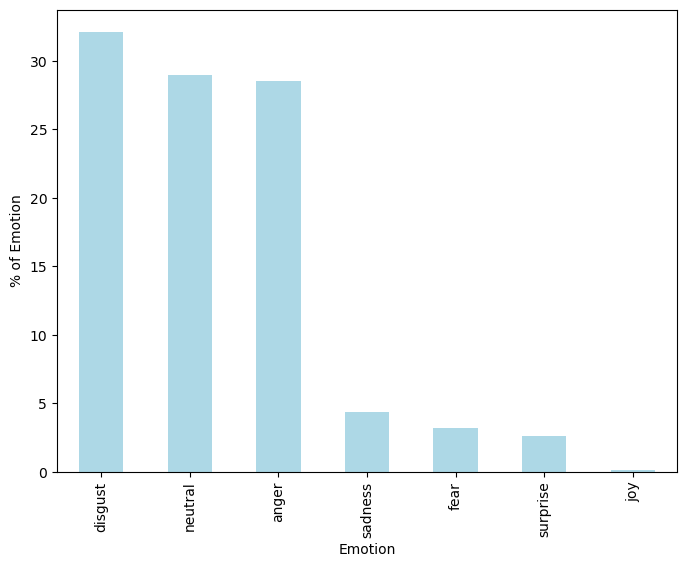

In [8]:
import matplotlib.pyplot as plt

# Calculate percentage contribution of each emotion
emotion_counts = df['predictedemotion'].value_counts(normalize=True) * 100

# Plot bar chart
plt.figure(figsize=(8,6))
emotion_counts.plot(kind='bar', color='#ADD8E6')

# Labels
plt.xlabel("Emotion")
plt.ylabel("% of Emotion")

# Remove title
plt.title("")

plt.show()


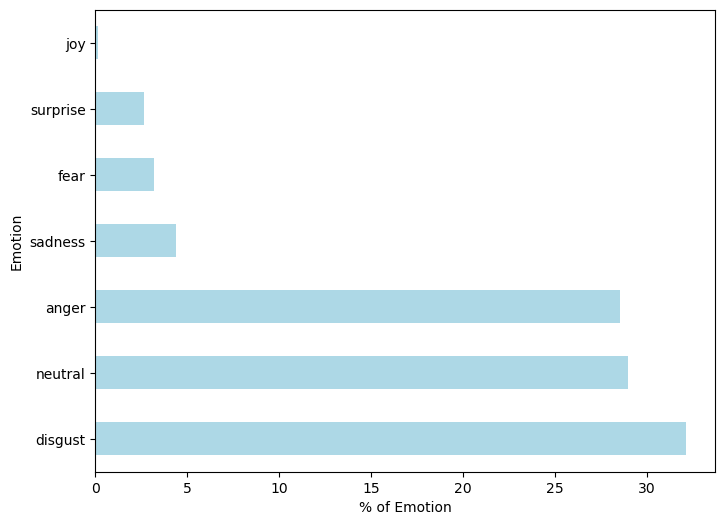

In [10]:
import matplotlib.pyplot as plt

# Calculate percentage contribution of each emotion
emotion_counts = df['predictedemotion'].value_counts(normalize=True) * 100

# Plot horizontal bar chart
plt.figure(figsize=(8,6))
emotion_counts.plot(kind='barh', color='#ADD8E6')

# Labels
plt.ylabel("Emotion")
plt.xlabel("% of Emotion")

# Remove title
plt.title("")
plt.savefig('distribution of emotion new.png')

plt.show()


In [11]:
!pip install YAKE


   ---------------------------------------- 0/2 [segtok]
   -------------------- ------------------- 1/2 [YAKE]
   ---------------------------------------- 2/2 [YAKE]



In [12]:
import pandas as pd
import yake

# Parameters for YAKE
language = "en"
max_ngram_size = 2  # unigrams & bigrams
num_keywords = 20

# Dictionary to store keywords for each emotion
emotion_keywords = {}

# Loop through each unique emotion
for emotion in df['predictedemotion'].unique():
    # Get all text for this emotion
    emotion_texts = df.loc[df['predictedemotion'] == emotion, 'thread_text_translated']
    combined_text = " ".join(emotion_texts.astype(str))  # join into one big doc

    # Initialize YAKE keyword extractor
    custom_kw_extractor = yake.KeywordExtractor(lan=language,
                                                n=max_ngram_size,
                                                top=num_keywords)
    
    # Extract keywords
    keywords = custom_kw_extractor.extract_keywords(combined_text)

    # Store just the words (or keep with scores if you want)
    emotion_keywords[emotion] = [kw for kw, score in keywords]

# Convert to dataframe for easy viewing
keywords_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in emotion_keywords.items()]))

keywords_df


,disgust,neutral,sadness,anger,joy,surprise,fear
0,water,water,water,water,Water,water,water
1,nokia water,hot water,n’t,Nokia water,months,Nokia Water,n’t
2,drinking water,floor heating,birth,Nokia,easier,Nokia,child water
3,n’t,water heating,child water,water plant,eating,Technical water,water vaccine
4,hot water,Heating,time,clean water,operation,drinking water,child
5,drink water,heat,child,drinking water,good,water supply,birth
6,clean water,warm water,born,n’t,Small success,n’t,give birth
7,Nokia,water heat,long time,water supply,life,clean water,drinking water
8,water plant,heating water,give birth,technical water,success experiences,water park,Nokia
9,cold water,water pump,good,Finland,concert,water pipeline,time


In [14]:
!pip install keybert


   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   ---------------------------------------- 0/2 [sentence-transformers]
   -------------------- ------------------- 1/2 [keybert]
   --

In [15]:
from keybert import KeyBERT
import pandas as pd

# Initialize KeyBERT model
kw_model = KeyBERT()

# Dictionary to store keywords for each emotion
emotion_keywords = {}

# Loop through each unique emotion
for emotion in df['predictedemotion'].unique():
    # Get all text for this emotion
    emotion_texts = df.loc[df['predictedemotion'] == emotion, 'thread_text_translated']
    combined_text = " ".join(emotion_texts.astype(str))  # join into one big doc

    # Extract keywords (top 20)
    keywords = kw_model.extract_keywords(
        combined_text,
        keyphrase_ngram_range=(1, 2),  # unigrams & bigrams
        stop_words='english',
        top_n=20
    )

    # Store just the words (or keep with scores if you want)
    emotion_keywords[emotion] = [word for word, score in keywords]

# Convert to dataframe for easy viewing
keywords_df = pd.DataFrame(dict([(k, pd.Series(v)) for k,v in emotion_keywords.items()]))

keywords_df


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\kvishal22\AppData\Local\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kvishal22\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,disgust,neutral,sadness,anger,joy,surprise,fear
0,pool severe,water advice,kaic treatments,boiler expensive,water better,mysterious dairy,diagnosed water
1,treatments botox,zinced tank,botulin treatments,heating expensive,surgery intestine,yogurt summer,water sick
2,pool abdomen,clean water,proper treatment,heating costs,make surgery,dairy luckily,symptoms water
3,toxins pool,zr water,treatments jump,boiler price,water good,dairy,problems water
4,water painful,use heatwater,alternatives treatment,boiler cheap,toilet live,water food,contamination water
5,symptomatic worried,water normal,treatment option,costs heating,toilet,letters foods,sick water
6,healing recovery,warm waterlths,early rehabilitation,heating cost,love water,water orders,water situation
7,symptomatic advanced,mineral water,use physiotherapypalloll,cost heating,reduced water,water meal,virus water
8,treatments helpful,zinc rarely,survive treatment,boiler cheapest,happy water,canapata milk,water vaccination
9,fluid therapy,water burns,treatments,heating profitable,liters water,water available,water scarring


In [70]:

import pandas as pd

# Load the CSV file into a DataFrame
# df = pd.read_csv('/content/emotion_keywords.csv')

# Melt the DataFrame to create 'emotions' and 'keyphrase' columns
df_melted = keywords_df.melt(var_name='emotions', value_name='keywords')

# Drop rows with missing values
df_melted.dropna(subset=['keywords'], inplace=True)

# Convert all keywords to lowercase
df_melted['keywords'] = df_melted['keywords'].str.lower()

# Convert the DataFrame to a LaTeX table and print it
latex_table = df_melted.to_latex(index=False)
print(latex_table)


\begin{tabular}{ll}
\toprule
emotions & keywords \\
\midrule
sadness & water \\
sadness & n’t \\
sadness & birth \\
sadness & child \\
sadness & child water \\
sadness & born \\
sadness & good \\
sadness & day \\
sadness & time \\
sadness & baby \\
sadness & baby water \\
sadness & pain \\
sadness & hospital \\
sadness & giving birth \\
sadness & contractions \\
sadness & birth started \\
sadness & gave birth \\
sadness & days \\
sadness & hours \\
sadness & waters \\
disgust & water \\
disgust & n’t \\
disgust & drinking water \\
disgust & clean water \\
disgust & drink water \\
disgust & nokia water \\
disgust & drink \\
disgust & hot water \\
disgust & n’t drink \\
disgust & salt water \\
disgust & pat water \\
disgust & nokia \\
disgust & technical water \\
disgust & waste water \\
disgust & waters \\
disgust & dirty water \\
disgust & water drinks \\
disgust & raw water \\
disgust & day \\
disgust & water washing \\
fear & water \\
fear & n’t \\
fear & child water \\
fear & drinki

In [16]:
keywords_df.to_csv("emotion_keywords new.csv", index=False)

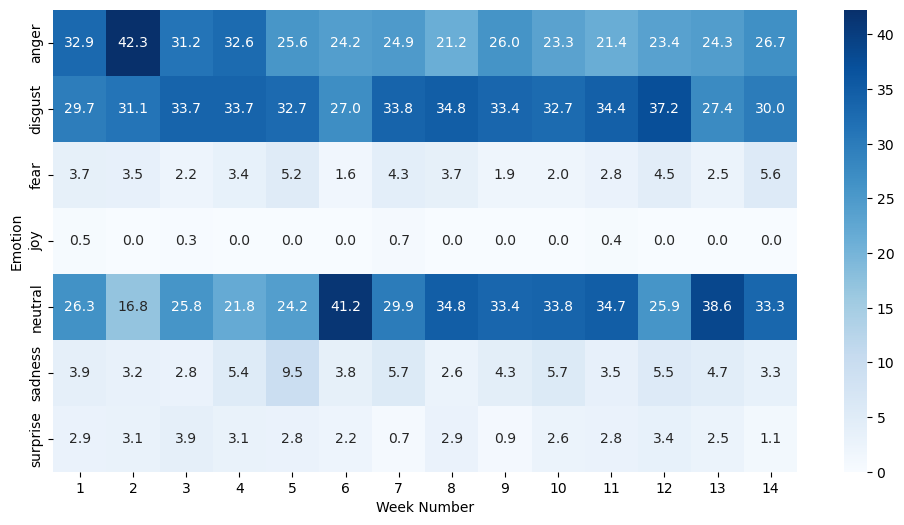

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['week_number'], normalize='columns') * 100

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(emotion_week, cmap="Blues", annot=True, fmt=".1f")

# Labels
plt.xlabel("Week Number")
plt.ylabel("Emotion")
plt.title("")
plt.savefig('hmweeklydistributionofemotionsnew.png')

plt.show()


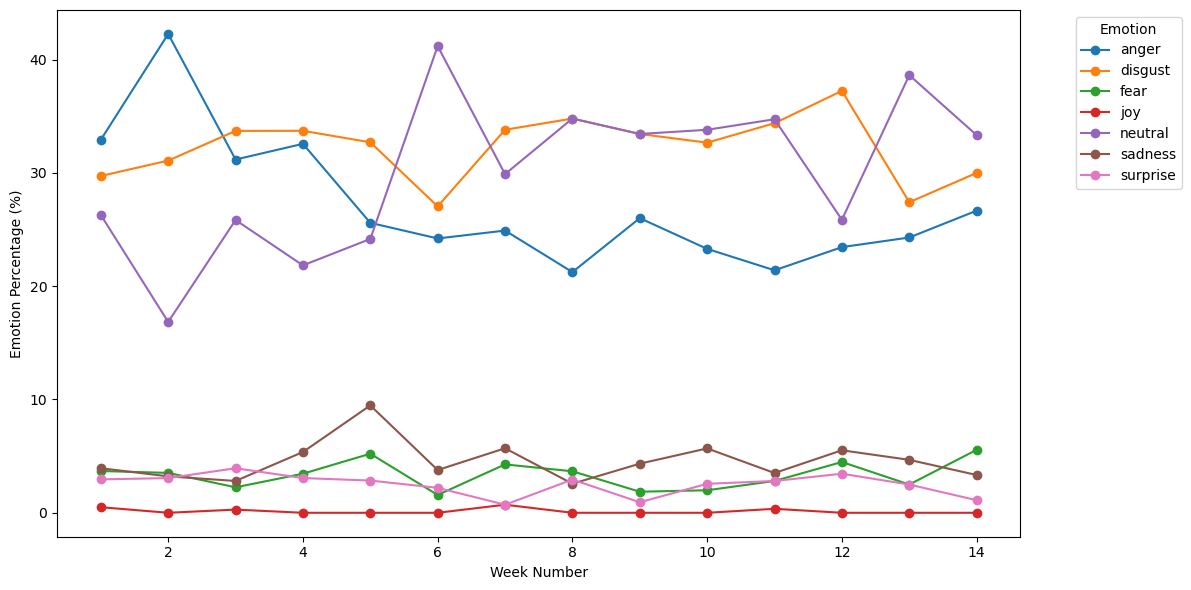

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['week_number'], normalize='columns') * 100

# Transpose for plotting: now rows = weeks, columns = emotions
emotion_week_t = emotion_week.T

# Plot line plot
plt.figure(figsize=(12, 6))
for emotion in emotion_week_t.columns:
    plt.plot(emotion_week_t.index, emotion_week_t[emotion], marker='o', label=emotion)

# Labels and title
plt.xlabel("Week Number")
plt.ylabel("Emotion Percentage (%)")
#plt.title("Weekly Distribution of Emotions")
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save plot
plt.savefig('weeklydistributionofemotions_lineplot new.png')

plt.show()


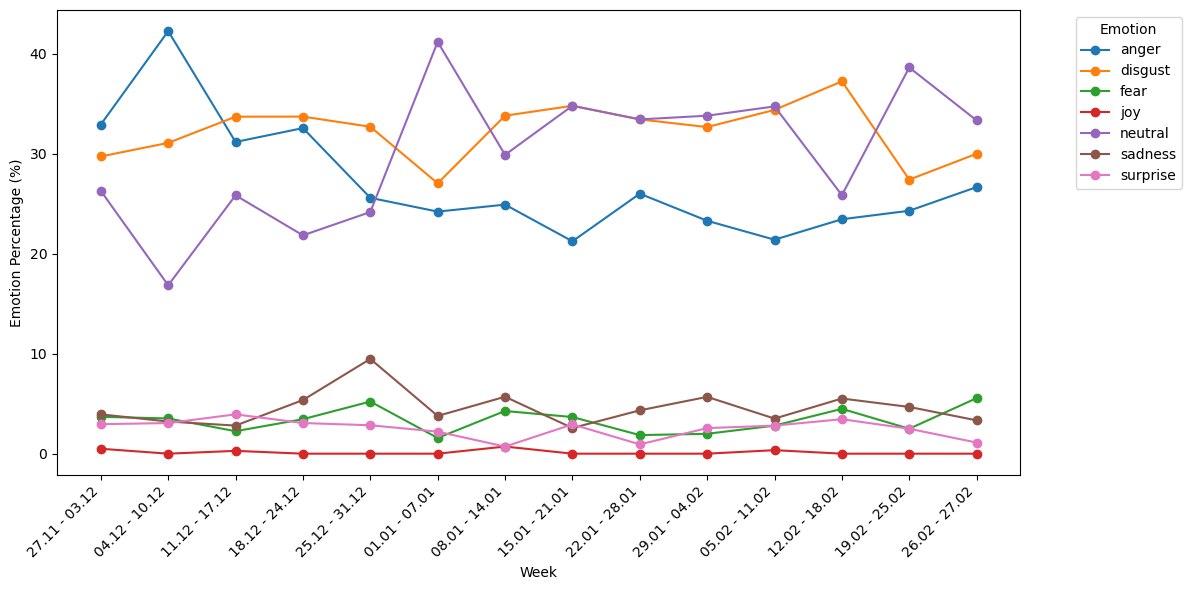

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['week_number'], normalize='columns') * 100

# Transpose for plotting: now rows = weeks, columns = emotions
emotion_week_t = emotion_week.T

# Add the formatted week label for each week_number
week_labels = df.drop_duplicates('week_number').sort_values('week_number')[['week_number', 'week']]
emotion_week_t = emotion_week_t.merge(week_labels, left_index=True, right_on='week_number', how='left')

# Plot line plot
plt.figure(figsize=(12, 6))
for emotion in emotion_week_t.columns[:-2]:  # exclude week_number and week columns
    plt.plot(emotion_week_t['week'], emotion_week_t[emotion], marker='o', label=emotion)

# Labels and title
plt.xlabel("Week")
plt.ylabel("Emotion Percentage (%)")
# plt.title("Weekly Distribution of Emotions")
plt.xticks(rotation=45, ha='right')  # Rotate labels for better visibility
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save plot
plt.savefig('nokia_weeklydistributionofemotions_lineplot_new.png', dpi=300)

plt.show()


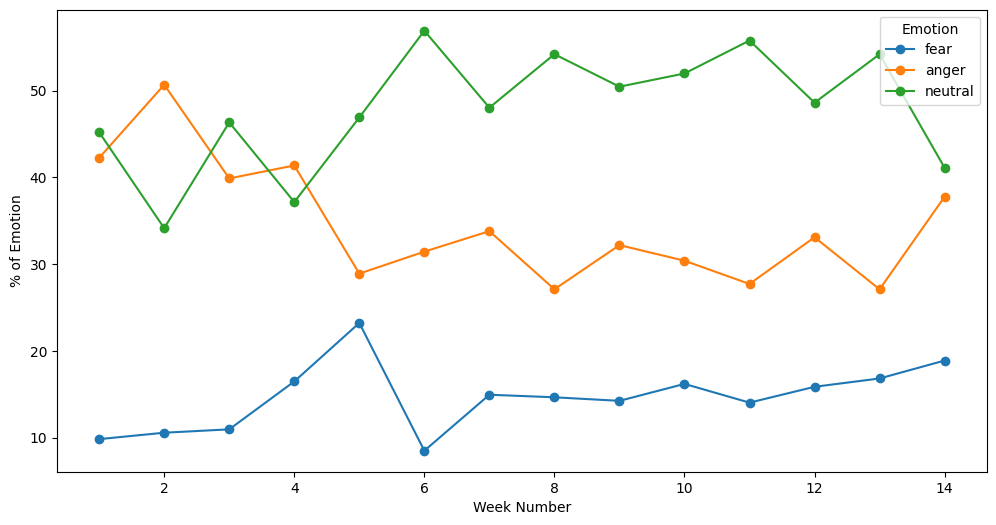

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['week_number'], normalize='columns') * 100

# Filter only the desired emotions
selected_emotions = ['fear', 'anger', 'neutral']
emotion_week_filtered = emotion_week.loc[selected_emotions]

# Plot line chart
plt.figure(figsize=(12,6))
for emotion in selected_emotions:
    plt.plot(emotion_week_filtered.columns, emotion_week_filtered.loc[emotion], marker='o', label=emotion)

# Labels
plt.xlabel("Week Number")
plt.ylabel("% of Emotion")
plt.title("")
plt.legend(title="Emotion")

plt.savefig('weeklydistributionofemotions_lineplot.png')
plt.show()


In [ ]:
#Canada

In [38]:
import pandas as pd
df = pd.read_csv('canada_predicted_output.csv')
df.columns

Index(['Unnamed: 0', 'post_id', 'title', 'selftext', 'author', 'score', 'url',
       'created_utc', 'num_comments', 'comment_id', 'body', 'named_entities',
       'entity_texts', 'entity_labels', 'predicted_labels',
       'predictedemotion'],
      dtype='object')

In [39]:
df['predictedemotion'].value_counts()

predictedemotion
anger       828
neutral     740
disgust     182
surprise    129
sadness      69
fear         19
joy          10
Name: count, dtype: int64

In [40]:
df['created_utc'] = pd.to_datetime(df['created_utc'], errors='coerce')

# Extract only date part
df['date'] = df['created_utc'].dt.date

print(df[['created_utc', 'date']].head())

          created_utc        date
0 2021-12-05 18:21:58  2021-12-05
1 2021-12-06 07:50:23  2021-12-06
2 2021-10-18 14:08:25  2021-10-18
3 2021-10-18 16:14:04  2021-10-18
4 2021-10-18 14:12:33  2021-10-18


In [41]:
df['date'].min()

datetime.date(2021, 2, 11)

In [42]:
df['date'].max()

datetime.date(2022, 12, 12)

In [43]:


# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Create custom month index starting from 1
min_date = df['date'].min()
df['month_number'] = ((df['date'].dt.year - min_date.year) * 12 +
                      (df['date'].dt.month - min_date.month) + 1)

# Group by custom month_number and get min and max date per group
month_ranges = df.groupby('month_number')['date'].agg(['min', 'max']).reset_index()
month_ranges.columns = ['month_number', 'start_date', 'end_date']

print(month_ranges)

# Count values per month
print(df['month_number'].value_counts())


    month_number start_date   end_date
0              1 2021-02-11 2021-02-12
1              3 2021-04-15 2021-04-30
2              4 2021-05-09 2021-05-11
3              8 2021-09-14 2021-09-30
4              9 2021-10-01 2021-10-26
5             10 2021-11-13 2021-11-18
6             11 2021-12-04 2021-12-06
7             12 2022-01-15 2022-01-22
8             13 2022-02-07 2022-02-24
9             14 2022-03-03 2022-03-28
10            15 2022-04-01 2022-04-26
11            16 2022-05-01 2022-05-27
12            17 2022-06-06 2022-06-26
13            18 2022-07-05 2022-07-24
14            19 2022-08-27 2022-08-31
15            20 2022-09-01 2022-09-10
16            21 2022-10-05 2022-10-23
17            22 2022-11-15 2022-11-28
18            23 2022-12-10 2022-12-12
month_number
9     800
8     270
19    192
15    136
10    100
11     84
14     71
3      71
18     47
16     39
13     32
12     32
17     25
21     20
22     17
20     13
23     13
4      12
1       3
Name: count, dtyp

In [44]:
# Ensure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Create short month label (e.g., "Jan 2021")
df['month'] = df['date'].dt.strftime('%b %Y')

# Optional: custom month index starting from 1
min_date = df['date'].min()
df['month_number'] = ((df['date'].dt.year - min_date.year) * 12 +
                      (df['date'].dt.month - min_date.month) + 1)

print(df[['date', 'month_number', 'month']].head())


        date  month_number     month
0 2021-12-05            11  Dec 2021
1 2021-12-06            11  Dec 2021
2 2021-10-18             9  Oct 2021
3 2021-10-18             9  Oct 2021
4 2021-10-18             9  Oct 2021


C:\Users\WGuser\AppData\Local\Temp\ipykernel_6824\3951780490.py:65: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')
C:\Users\WGuser\AppData\Local\Temp\ipykernel_6824\3951780490.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')


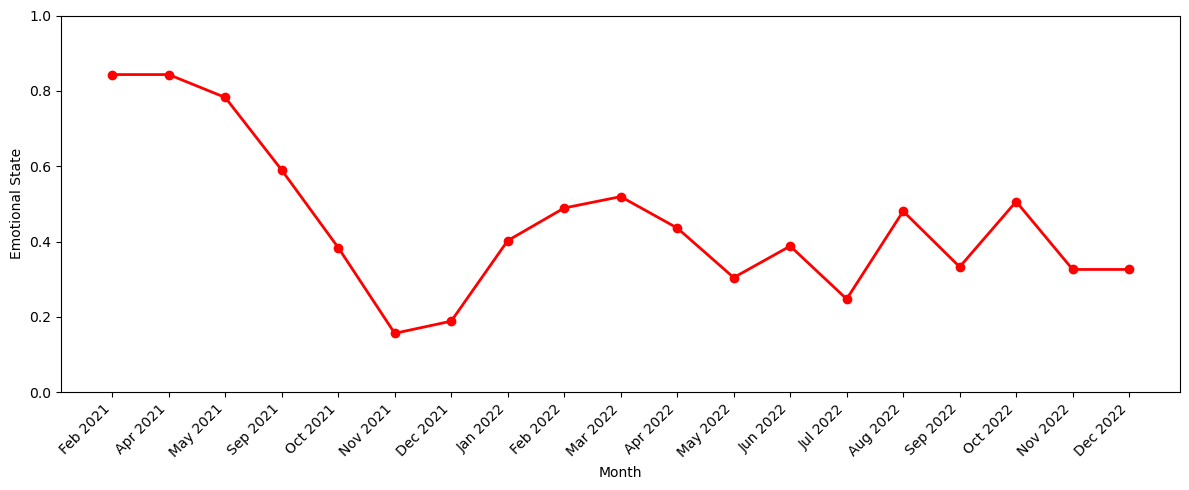

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Aggregate emotions per week
# -----------------------------

# Make sure weeks are in order
df = df.sort_values('month_number')

# Count how many times each emotion appears per week_number
emotion_counts = (
    df.groupby(['month_number', 'predictedemotion'])
      .size()
      .unstack(fill_value=0)
)

# Ensure all emotion columns exist (including surprise)
all_emotions = ['anger', 'fear', 'disgust', 'sadness', 'joy', 'neutral', 'surprise']
for e in all_emotions:
    if e not in emotion_counts.columns:
        emotion_counts[e] = 0

# Sort by week_number just to be safe
emotion_counts = emotion_counts.sort_index()

# -----------------------------------
# 2. Convert counts to proportions (%)
# -----------------------------------

emotion_props = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

# ---------------------------------------------------
# 3. FEMA-style emotional elevation index (HIGH = good)
# ---------------------------------------------------
# Positive / stabilising: joy + neutral
# Negative / distress: anger + fear + disgust + sadness + surprise

emotion_props['emotional_elevation'] = (
    emotion_props[['joy', 'neutral']].sum(axis=1)
    - emotion_props[['anger', 'fear', 'disgust', 'sadness', 'surprise']].sum(axis=1)
)

# -------------------------------
# 4. Normalise elevation to 0–1
# -------------------------------

x = emotion_props['emotional_elevation']
emin, emax = x.min(), x.max()

if emax > emin:
    emotion_props['elev_scaled'] = (x - emin) / (emax - emin)
else:
    # Edge case: if all weeks have same value
    emotion_props['elev_scaled'] = 0.5

# -------------------------------
# 5. Smooth the curve (rolling)
# -------------------------------

emotion_props['elev_smooth'] = (
    emotion_props['elev_scaled']
    .rolling(window=3, center=True)   # you can change window size (e.g., 2 or 4)
    .mean()
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ---------------------------------------
# 6. Attach human-readable week labels
# ---------------------------------------

week_labels = (
    df[['month_number', 'month']]
    .drop_duplicates()
    .sort_values('month_number')
)

plot_df = (
    emotion_props
    .reset_index()  # bring week_number out of the index
    .merge(week_labels, on='month_number', how='left')
)

# ----------------
# 7. Plot the line
# ----------------

plt.figure(figsize=(12, 5))

#Example: mark approximate phase transitions by week_number


plt.plot(plot_df['month'], plot_df['elev_smooth'],
         marker='o', linewidth=2, color='red')

plt.xlabel("Month")
plt.ylabel("Emotional State")
# plt.title("FEMA-style Emotional Trajectory – Nokia Water Crisis")
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])


plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('canada_fema_emotional_elevation_curve.png', dpi=300)
plt.show()


In [25]:
import pandas as pd
import re

def dataset_statistics(df, date_col='date', text_col='body'):
    # Ensure date column is datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Tokenize by splitting on whitespace after removing punctuation
    df['tokens'] = df[text_col].apply(lambda x: re.findall(r'\w+', str(x).lower()))
    token_counts = df['tokens'].apply(len)

    # Average tokens per comment
    avg_tokens_per_comment = token_counts.mean()

    # Min & max tokens per comment
    min_tokens = token_counts.min()
    max_tokens = token_counts.max()

    # Average comments per day
    comments_per_day = df.groupby(df[date_col].dt.date).size()
    avg_comments_per_day = comments_per_day.mean()

    # Vocabulary size (unique words)
    vocab = set([token for tokens in df['tokens'] for token in tokens])
    vocab_size = len(vocab)

    return {
        'Average Tokens per Comment': round(avg_tokens_per_comment, 2),
        'Min Tokens per Comment': min_tokens,
        'Max Tokens per Comment': max_tokens,
        'Average Comments per Day': round(avg_comments_per_day, 2),
        'Vocabulary Size': vocab_size
    }

# Example usage:
stats = dataset_statistics(df)
print(stats)

{'Average Tokens per Comment': np.float64(32.87), 'Min Tokens per Comment': 0, 'Max Tokens per Comment': 454, 'Average Comments per Day': np.float64(16.48), 'Vocabulary Size': 6660}


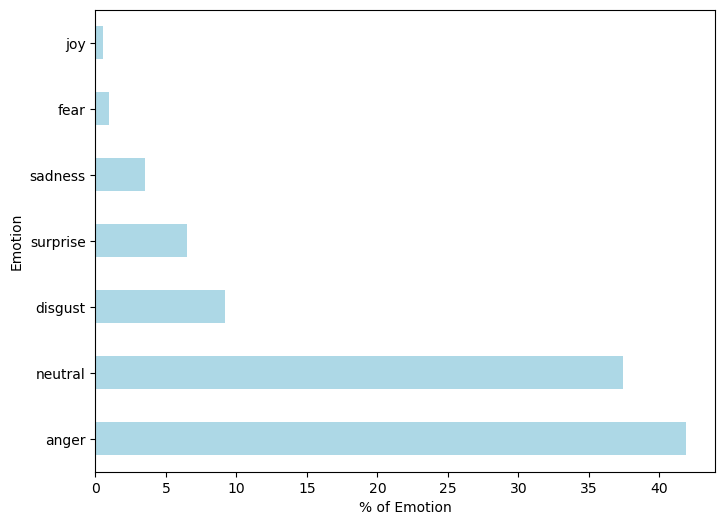

In [26]:
import matplotlib.pyplot as plt

# Calculate percentage contribution of each emotion
emotion_counts = df['predictedemotion'].value_counts(normalize=True) * 100

# Plot horizontal bar chart
plt.figure(figsize=(8,6))
emotion_counts.plot(kind='barh', color='#ADD8E6')

# Labels
plt.ylabel("Emotion")
plt.xlabel("% of Emotion")

# Remove title
plt.title("")
plt.savefig('canada_distribution of emotion new.png')

plt.show()

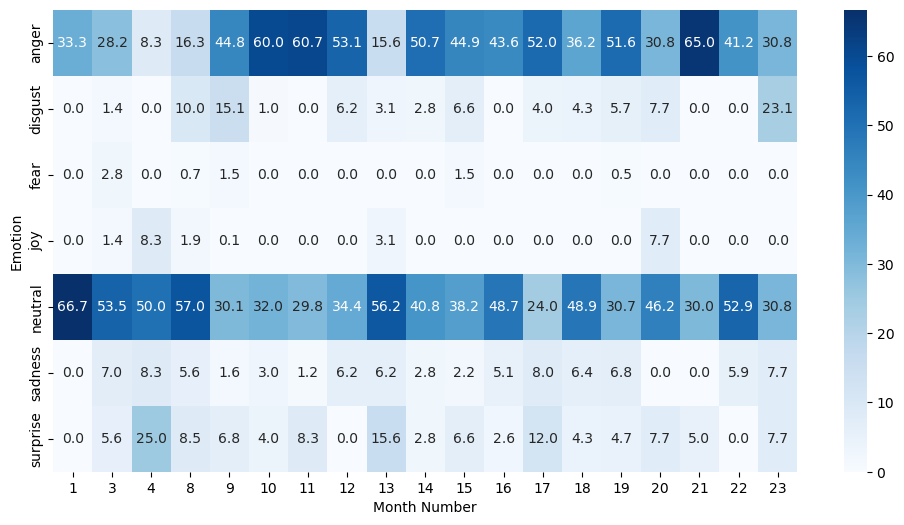

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['month_number'], normalize='columns') * 100

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(emotion_week, cmap="Blues", annot=True, fmt=".1f")

# Labels
plt.xlabel("Month Number")
plt.ylabel("Emotion")
plt.title("")
plt.savefig('hmcanadamonthlydistributionofemotionsnew.png')

plt.show()


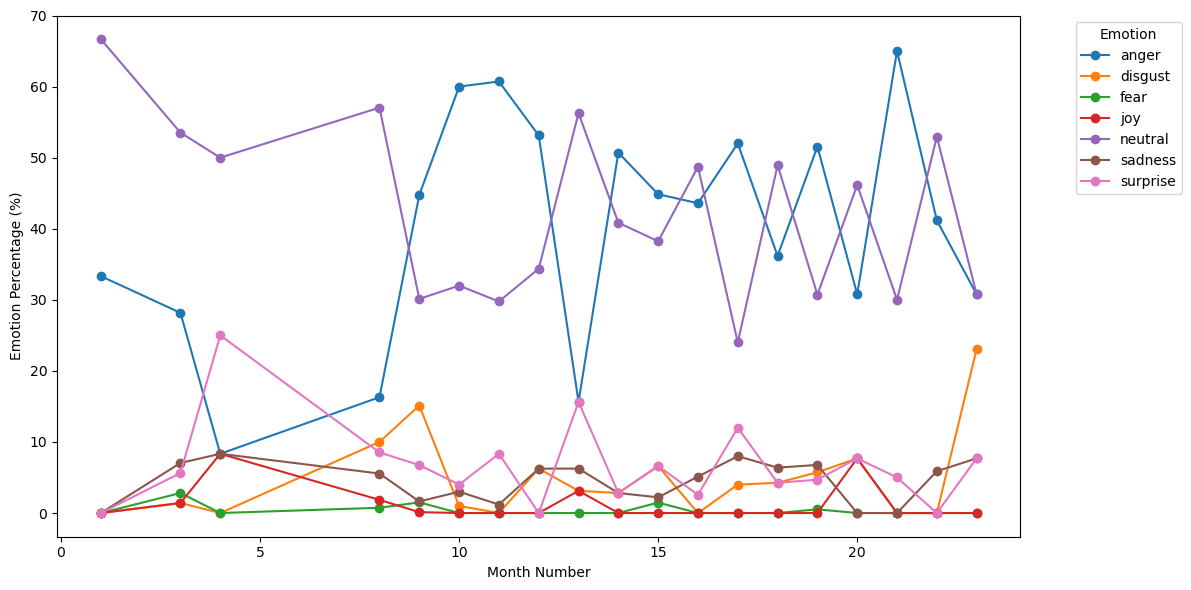

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['month_number'], normalize='columns') * 100

# Transpose for plotting: now rows = weeks, columns = emotions
emotion_week_t = emotion_week.T

# Plot line plot
plt.figure(figsize=(12, 6))
for emotion in emotion_week_t.columns:
    plt.plot(emotion_week_t.index, emotion_week_t[emotion], marker='o', label=emotion)

# Labels and title
plt.xlabel("Month Number")
plt.ylabel("Emotion Percentage (%)")
plt.title("")
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save plot
plt.savefig('monthlydistributionofemotions_lineplotnew.png')

plt.show()


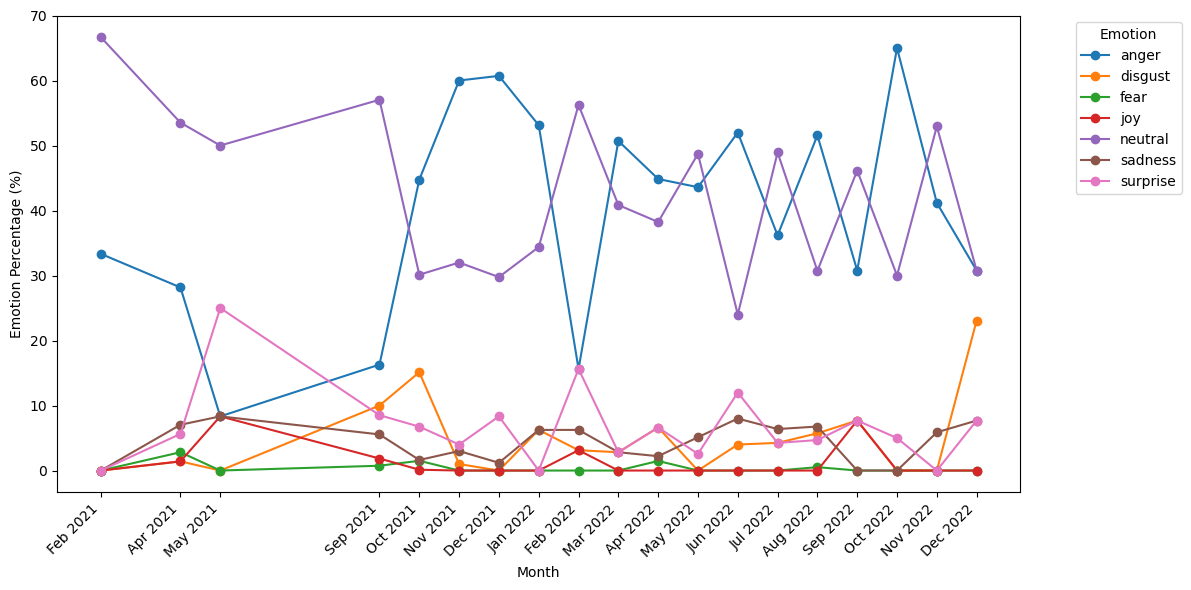

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of month_number vs emotion (normalized to % per month)
emotion_month = pd.crosstab(df['predictedemotion'], df['month_number'], normalize='columns') * 100

# Transpose for plotting (rows = months, columns = emotions)
emotion_month_t = emotion_month.T

# Map month_number to month names (e.g., Jan 2021)
month_labels = df.drop_duplicates('month_number').sort_values('month_number')['month'].tolist()

# Plot
plt.figure(figsize=(12, 6))
for emotion in emotion_month_t.columns:
    plt.plot(emotion_month_t.index, emotion_month_t[emotion], marker='o', label=emotion)

# Replace x-axis ticks with month names
plt.xticks(ticks=emotion_month_t.index, labels=month_labels, rotation=45, ha='right')

# Labels and title
plt.xlabel("Month")
plt.ylabel("Emotion Percentage (%)")
plt.title("")
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('iqaluit_monthlydistributionofemotions_lineplotnew.png')
plt.show()


In [30]:
import pandas as pd
import yake

# Parameters for YAKE
language = "en"
max_ngram_size = 2  # unigrams & bigrams
num_keywords = 20

# Dictionary to store keywords for each emotion
emotion_keywords = {}

# Loop through each unique emotion
for emotion in df['predictedemotion'].unique():
    # Get all text for this emotion
    emotion_texts = df.loc[df['predictedemotion'] == emotion, 'body']
    combined_text = " ".join(emotion_texts.astype(str))  # join into one big doc

    # Initialize YAKE keyword extractor
    custom_kw_extractor = yake.KeywordExtractor(lan=language,
                                                n=max_ngram_size,
                                                top=num_keywords)
    
    # Extract keywords
    keywords = custom_kw_extractor.extract_keywords(combined_text)

    # Store just the words (or keep with scores if you want)
    emotion_keywords[emotion] = [kw for kw, score in keywords]

# Convert to dataframe for easy viewing
keywords_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in emotion_keywords.items()]))

keywords_df


,anger,neutral,surprise,disgust,fear,sadness,joy
0,water,Canada,Water,water,Exceedingly high,Iqaluit Nunavut,pies
1,people,d'une province,Iqaluit,removed,Lake Geraldine,Flint-level water,Wow
2,water treatment,province,oil spill,water supply,water,water,happy
3,drinking water,Cette soumission,oil,water treatment,high concentrations,people,beautiful
4,government,une province,Nunavut,drink,Lake,Iqaluit water,Labrador Sea
5,Iqaluit,d'une,drinking water,drinking water,Geraldine Lake,live,Sea
6,Canada,d'une autre,water tank,Iqaluit,Geraldine,communities,THHHEEMMMM
7,Indigenous people,subreddit,spill,tank,PFAS,Iqaluit,open
8,Nunavut,résidents d'une,people,diesel,concentrations,Sad,n’t
9,city,d'une ville,tank,City,normal concentrations,Flint-level,excitement


In [31]:

import pandas as pd

# Load the CSV file into a DataFrame
# df = pd.read_csv('/content/emotion_keywords.csv')

# Melt the DataFrame to create 'emotions' and 'keyphrase' columns
df_melted = keywords_df.melt(var_name='emotions', value_name='keywords')

# Drop rows with missing values
df_melted.dropna(subset=['keywords'], inplace=True)

# Convert all keywords to lowercase
df_melted['keywords'] = df_melted['keywords'].str.lower()

# Convert the DataFrame to a LaTeX table and print it
latex_table = df_melted.to_latex(index=False)
print(latex_table)


\begin{tabular}{ll}
\toprule
emotions & keywords \\
\midrule
anger & water \\
anger & people \\
anger & water treatment \\
anger & drinking water \\
anger & government \\
anger & iqaluit \\
anger & canada \\
anger & indigenous people \\
anger & nunavut \\
anger & city \\
anger & clean water \\
anger & nunavut government \\
anger & n’t \\
anger & tap water \\
anger & bottled water \\
anger & water system \\
anger & water supply \\
anger & federal government \\
anger & canadian government \\
anger & money \\
neutral & canada \\
neutral & d'une province \\
neutral & province \\
neutral & cette soumission \\
neutral & une province \\
neutral & d'une \\
neutral & d'une autre \\
neutral & subreddit \\
neutral & résidents d'une \\
neutral & d'une ville \\
neutral & pas \\
neutral & n'autorisons pas \\
neutral & n'est pas \\
neutral & pas autorisé \\
neutral & cette \\
neutral & deleted \\
neutral & performed automatically \\
neutral & prejudice \\
neutral & soumission semble \\
neutral & néga

In [ ]:
#Flint

In [46]:
df = pd.read_csv('usa_predicted_output.csv')
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'post_id', 'title', 'selftext', 'author',
       'score', 'url', 'created_utc', 'num_comments', 'comment_id', 'body',
       'predicted_labels', 'predicted_labelsold', 'named_entities',
       'entity_texts', 'entity_labels', 'predictedemotion'],
      dtype='object')

In [47]:
df['predictedemotion'].value_counts()

predictedemotion
anger       14615
neutral      4933
disgust      1402
surprise     1049
sadness       540
fear          140
joy            45
Name: count, dtype: int64

In [48]:
len(df)

22724

In [49]:
df['created_utc'] = pd.to_datetime(df['created_utc'], errors='coerce')

# Extract only date part
df['date'] = df['created_utc'].dt.date

print(df[['created_utc', 'date']].head())

          created_utc        date
0 2025-03-05 12:08:29  2025-03-05
1 2025-03-05 16:00:51  2025-03-05
2 2025-03-04 23:54:18  2025-03-04
3 2025-03-05 01:22:49  2025-03-05
4 2025-03-05 17:19:50  2025-03-05


In [50]:


# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])

# Get minimum date
min_date = df['date'].min()

# Create custom year index starting from 1
df['year_number'] = (df['date'].dt.year - min_date.year) + 1

# Group by custom year_number and get min and max date
year_ranges = df.groupby('year_number')['date'].agg(['min', 'max']).reset_index()
year_ranges.columns = ['year_number', 'start_date', 'end_date']

print(year_ranges)

# Count values per year_number
print(df['year_number'].value_counts())


    year_number start_date   end_date
0             1 2015-07-21 2015-12-19
1             2 2016-01-13 2016-12-31
2             3 2017-01-01 2017-12-27
3             4 2018-01-13 2018-12-21
4             5 2019-01-02 2019-12-23
5             6 2020-01-09 2020-12-31
6             7 2021-01-01 2021-12-13
7             8 2022-01-17 2022-12-14
8             9 2023-03-02 2023-12-16
9            10 2024-02-02 2024-11-28
10           11 2025-01-27 2025-03-09
year_number
2     7536
3     4666
4     4547
7     1429
5     1399
8      965
6      942
10     671
9      479
11      74
1       16
Name: count, dtype: int64


In [51]:
# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'])

# Get minimum date
min_date = df['date'].min()

# Create custom year index starting from 1
df['year_number'] = (df['date'].dt.year - min_date.year) + 1

# Create actual year column (e.g., 2014, 2015, ...)
df['year'] = df['date'].dt.year

# Group by custom year_number and get min, max, and actual year
year_ranges = (
    df.groupby('year_number')
      .agg(start_date=('date', 'min'), end_date=('date', 'max'))
      .reset_index()
)

# Add year column based on start_date
year_ranges['year'] = year_ranges['start_date'].dt.year

print(year_ranges)
print(df[['date', 'year_number', 'year']].head())

# Count values per year_number
print(df['year_number'].value_counts())


    year_number start_date   end_date  year
0             1 2015-07-21 2015-12-19  2015
1             2 2016-01-13 2016-12-31  2016
2             3 2017-01-01 2017-12-27  2017
3             4 2018-01-13 2018-12-21  2018
4             5 2019-01-02 2019-12-23  2019
5             6 2020-01-09 2020-12-31  2020
6             7 2021-01-01 2021-12-13  2021
7             8 2022-01-17 2022-12-14  2022
8             9 2023-03-02 2023-12-16  2023
9            10 2024-02-02 2024-11-28  2024
10           11 2025-01-27 2025-03-09  2025
        date  year_number  year
0 2025-03-05           11  2025
1 2025-03-05           11  2025
2 2025-03-04           11  2025
3 2025-03-05           11  2025
4 2025-03-05           11  2025
year_number
2     7536
3     4666
4     4547
7     1429
5     1399
8      965
6      942
10     671
9      479
11      74
1       16
Name: count, dtype: int64


C:\Users\WGuser\AppData\Local\Temp\ipykernel_6824\2279802576.py:65: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='bfill')
C:\Users\WGuser\AppData\Local\Temp\ipykernel_6824\2279802576.py:66: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')


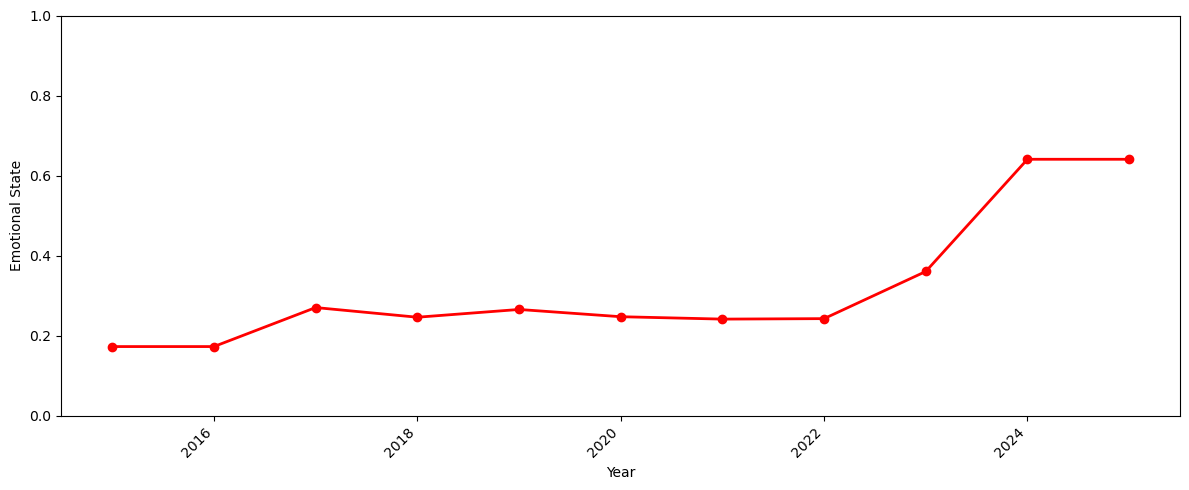

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Aggregate emotions per week
# -----------------------------

# Make sure weeks are in order
df = df.sort_values('year_number')

# Count how many times each emotion appears per week_number
emotion_counts = (
    df.groupby(['year_number', 'predictedemotion'])
      .size()
      .unstack(fill_value=0)
)

# Ensure all emotion columns exist (including surprise)
all_emotions = ['anger', 'fear', 'disgust', 'sadness', 'joy', 'neutral', 'surprise']
for e in all_emotions:
    if e not in emotion_counts.columns:
        emotion_counts[e] = 0

# Sort by week_number just to be safe
emotion_counts = emotion_counts.sort_index()

# -----------------------------------
# 2. Convert counts to proportions (%)
# -----------------------------------

emotion_props = emotion_counts.div(emotion_counts.sum(axis=1), axis=0)

# ---------------------------------------------------
# 3. FEMA-style emotional elevation index (HIGH = good)
# ---------------------------------------------------
# Positive / stabilising: joy + neutral
# Negative / distress: anger + fear + disgust + sadness + surprise

emotion_props['emotional_elevation'] = (
    emotion_props[['joy', 'neutral']].sum(axis=1)
    - emotion_props[['anger', 'fear', 'disgust', 'sadness', 'surprise']].sum(axis=1)
)

# -------------------------------
# 4. Normalise elevation to 0–1
# -------------------------------

x = emotion_props['emotional_elevation']
emin, emax = x.min(), x.max()

if emax > emin:
    emotion_props['elev_scaled'] = (x - emin) / (emax - emin)
else:
    # Edge case: if all weeks have same value
    emotion_props['elev_scaled'] = 0.5

# -------------------------------
# 5. Smooth the curve (rolling)
# -------------------------------

emotion_props['elev_smooth'] = (
    emotion_props['elev_scaled']
    .rolling(window=3, center=True)   # you can change window size (e.g., 2 or 4)
    .mean()
    .fillna(method='bfill')
    .fillna(method='ffill')
)

# ---------------------------------------
# 6. Attach human-readable week labels
# ---------------------------------------

week_labels = (
    df[['year_number', 'year']]
    .drop_duplicates()
    .sort_values('year_number')
)

plot_df = (
    emotion_props
    .reset_index()  # bring week_number out of the index
    .merge(week_labels, on='year_number', how='left')
)

# ----------------
# 7. Plot the line
# ----------------

plt.figure(figsize=(12, 5))

#Example: mark approximate phase transitions by week_number


plt.plot(plot_df['year'], plot_df['elev_smooth'],
         marker='o', linewidth=2, color='red')

plt.xlabel("Year")
plt.ylabel("Emotional State")
# plt.title("FEMA-style Emotional Trajectory – Nokia Water Crisis")
plt.ylim(0, 1)
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1])


plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('flint_fema_emotional_elevation_curve.png', dpi=300)
plt.show()


In [88]:
import pandas as pd
import re

def dataset_statistics(df, date_col='date', text_col='body'):
    # Ensure date column is datetime
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

    # Tokenize by splitting on whitespace after removing punctuation
    df['tokens'] = df[text_col].apply(lambda x: re.findall(r'\w+', str(x).lower()))
    token_counts = df['tokens'].apply(len)

    # Average tokens per comment
    avg_tokens_per_comment = token_counts.mean()

    # Min & max tokens per comment
    min_tokens = token_counts.min()
    max_tokens = token_counts.max()

    # Average comments per day
    comments_per_day = df.groupby(df[date_col].dt.date).size()
    avg_comments_per_day = comments_per_day.mean()

    # Vocabulary size (unique words)
    vocab = set([token for tokens in df['tokens'] for token in tokens])
    vocab_size = len(vocab)

    return {
        'Average Tokens per Comment': round(avg_tokens_per_comment, 2),
        'Min Tokens per Comment': min_tokens,
        'Max Tokens per Comment': max_tokens,
        'Average Comments per Day': round(avg_comments_per_day, 2),
        'Vocabulary Size': vocab_size
    }

# Example usage:
stats = dataset_statistics(df)
print(stats)

{'Average Tokens per Comment': np.float64(37.16), 'Min Tokens per Comment': 0, 'Max Tokens per Comment': 1868, 'Average Comments per Day': np.float64(32.56), 'Vocabulary Size': 25576}


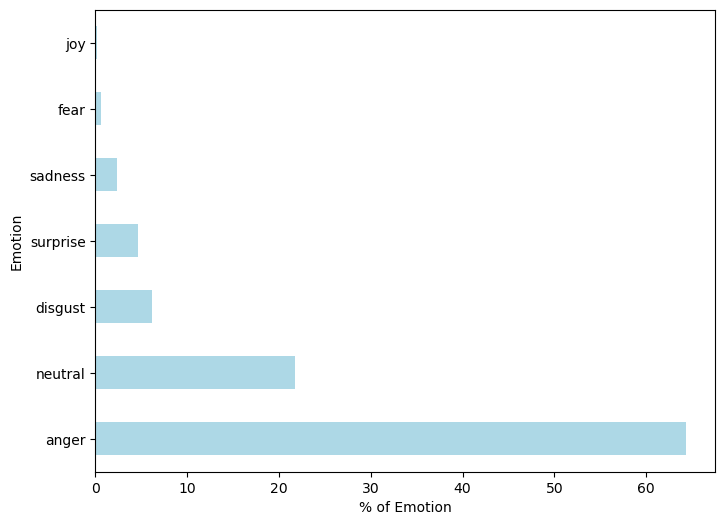

In [39]:
import matplotlib.pyplot as plt

# Calculate percentage contribution of each emotion
emotion_counts = df['predictedemotion'].value_counts(normalize=True) * 100

# Plot horizontal bar chart
plt.figure(figsize=(8,6))
emotion_counts.plot(kind='barh', color='#ADD8E6')

# Labels
plt.ylabel("Emotion")
plt.xlabel("% of Emotion")

# Remove title
plt.title("")
plt.savefig('flint_distribution of emotion new.png')

plt.show()

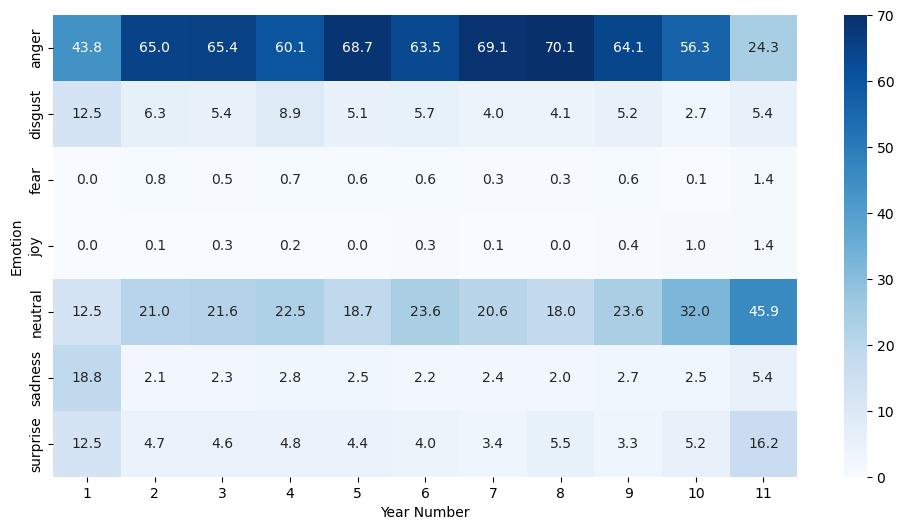

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['year_number'], normalize='columns') * 100

# Plot heatmap
plt.figure(figsize=(12,6))
sns.heatmap(emotion_week, cmap="Blues", annot=True, fmt=".1f")

# Labels
plt.xlabel("Year Number")
plt.ylabel("Emotion")
plt.title("")
plt.savefig('flintyearlydistributionofemotionsnew.png')

plt.show()

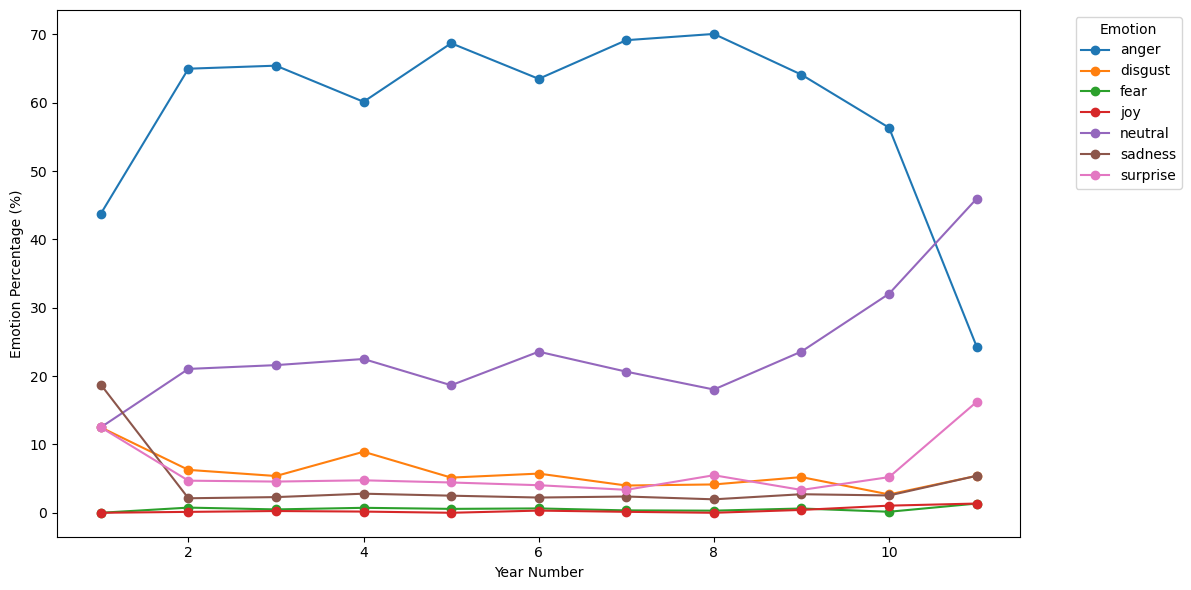

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of week_number vs emotion (normalized to % per week)
emotion_week = pd.crosstab(df['predictedemotion'], df['year_number'], normalize='columns') * 100

# Transpose for plotting: now rows = weeks, columns = emotions
emotion_week_t = emotion_week.T

# Plot line plot
plt.figure(figsize=(12, 6))
for emotion in emotion_week_t.columns:
    plt.plot(emotion_week_t.index, emotion_week_t[emotion], marker='o', label=emotion)

# Labels and title
plt.xlabel("Year Number")
plt.ylabel("Emotion Percentage (%)")
plt.title("")
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save plot
plt.savefig('yearlydistributionofemotions_lineplot.png')

plt.show()


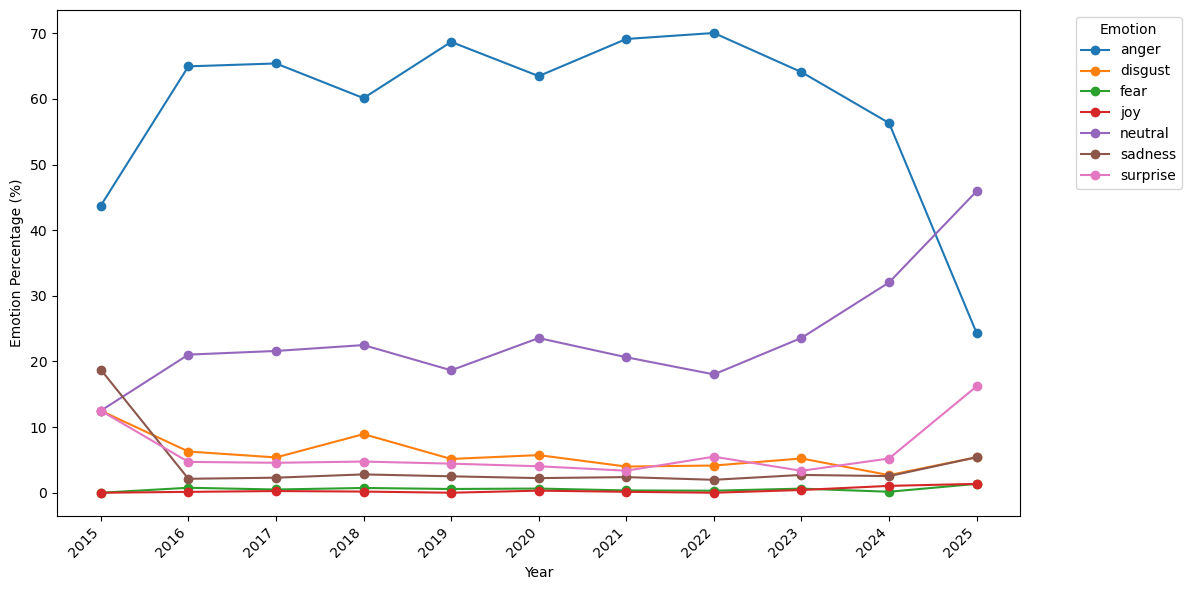

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a crosstab of year_number vs emotion (normalized to % per year)
emotion_year = pd.crosstab(df['predictedemotion'], df['year_number'], normalize='columns') * 100

# Transpose for plotting (rows = years, columns = emotions)
emotion_year_t = emotion_year.T

# Map year_number to actual years
year_labels = (
    df.drop_duplicates('year_number')
      .sort_values('year_number')['year']
      .tolist()
)

# Plot line plot
plt.figure(figsize=(12, 6))
for emotion in emotion_year_t.columns:
    plt.plot(emotion_year_t.index, emotion_year_t[emotion], marker='o', label=emotion)

# Replace x-axis ticks with actual years
plt.xticks(ticks=emotion_year_t.index, labels=year_labels, rotation=45, ha='right')

# Labels and title
plt.xlabel("Year")
plt.ylabel("Emotion Percentage (%)")
#plt.title("Yearly Emotion Distribution")
plt.legend(title='Emotion', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save and show
plt.savefig('flint_yearlydistributionofemotions_lineplot.png')
plt.show()


In [42]:
import pandas as pd
import yake

# Parameters for YAKE
language = "en"
max_ngram_size = 2  # unigrams & bigrams
num_keywords = 20

# Dictionary to store keywords for each emotion
emotion_keywords = {}

# Loop through each unique emotion
for emotion in df['predictedemotion'].unique():
    # Get all text for this emotion
    emotion_texts = df.loc[df['predictedemotion'] == emotion, 'body']
    combined_text = " ".join(emotion_texts.astype(str))  # join into one big doc

    # Initialize YAKE keyword extractor
    custom_kw_extractor = yake.KeywordExtractor(lan=language,
                                                n=max_ngram_size,
                                                top=num_keywords)
    
    # Extract keywords
    keywords = custom_kw_extractor.extract_keywords(combined_text)

    # Store just the words (or keep with scores if you want)
    emotion_keywords[emotion] = [kw for kw, score in keywords]

# Convert to dataframe for easy viewing
keywords_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in emotion_keywords.items()]))

keywords_df


,sadness,surprise,anger,neutral,fear,joy,disgust
0,flint,water,Flint Water,water,water,water,water
1,water,flint,Flint River,deleted,lead,good,lead
2,people,Flint Water,Flint,Flint,Flint,people,Flint water
3,flint water,lead,Detroit water,Flint water,flint water,happy,Flint
4,sad,water source,Water,Michigan,bad,Comma Bookstore,drinking water
5,water crisis,lead water,Flint city,State,n’t,work,tap water
6,time,thought,Flint Michigan,people,people,awesome,lead pipes
7,years,Good,Rick Snyder,drinking water,Lead Poisoning,glad,removed
8,bottled water,people,people,bottled water,pipes,Yay,lead water
9,clean water,years,river water,good,levels,city,lead levels


In [43]:

import pandas as pd

# Load the CSV file into a DataFrame
# df = pd.read_csv('/content/emotion_keywords.csv')

# Melt the DataFrame to create 'emotions' and 'keyphrase' columns
df_melted = keywords_df.melt(var_name='emotions', value_name='keywords')

# Drop rows with missing values
df_melted.dropna(subset=['keywords'], inplace=True)

# Convert all keywords to lowercase
df_melted['keywords'] = df_melted['keywords'].str.lower()

# Convert the DataFrame to a LaTeX table and print it
latex_table = df_melted.to_latex(index=False)
print(latex_table)


\begin{tabular}{ll}
\toprule
emotions & keywords \\
\midrule
sadness & flint \\
sadness & water \\
sadness & people \\
sadness & flint water \\
sadness & sad \\
sadness & water crisis \\
sadness & time \\
sadness & years \\
sadness & bottled water \\
sadness & clean water \\
sadness & lot \\
sadness & lead \\
sadness & bad \\
sadness & feel \\
sadness & back \\
sadness & michigan \\
sadness & live \\
sadness & move \\
sadness & n’t \\
sadness & died \\
surprise & water \\
surprise & flint \\
surprise & flint water \\
surprise & lead \\
surprise & water source \\
surprise & lead water \\
surprise & thought \\
surprise & good \\
surprise & people \\
surprise & years \\
surprise & pipes \\
surprise & thought flint \\
surprise & wow \\
surprise & flint river \\
surprise & read \\
surprise & time \\
surprise & surprised \\
surprise & flint michigan \\
surprise & water pipes \\
surprise & source \\
anger & flint water \\
anger & flint river \\
anger & flint \\
anger & detroit water \\
anger 